In [2]:
import argparse
import torch
import torch.nn as nn
import os
import pandas as pd
import yaml
from copy import deepcopy
import numpy as np
from tqdm import tqdm
from scipy import stats
from sklearn import metrics
from typing import List
import seaborn as sns
import matplotlib.pyplot as plt
from src.utils.constants import DEVICE
from matplotlib import rcParams, rcParamsDefault
import matplotlib.colors as mcolors

EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}


/Users/wanghan/miniconda3/envs/deepburst/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:


rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 5.5 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'k',   
        'xtick.labelsize': 5,
        'ytick.labelsize': 5,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        
        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )

sns.set_palette("colorblind")
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]



In [3]:
predictions = pd.read_csv('./extra/results/predictions_bs_bf.csv')
motifs = pd.read_csv('./benchmarks/revised_v2/reviewer1/results/gene_ids_with_labels.bed',sep='\t',usecols=['gene_id', 'tata_label', 'initiator_label', 'ccaat_label', 'gcbox_label']).drop_duplicates().reset_index(drop=True)
motifs

data = pd.merge(predictions, motifs, on='gene_id', how='left').fillna(0)


In [20]:
data

,gene_id,bs_label_label,bs_label_score,bs_label_pred,bf_label_label,bf_label_score,bf_label_pred,fold,eid,tata_label,initiator_label,ccaat_label,gcbox_label
0,ENSG00000132470,1,0.087409,0,0,0.137287,0,0,E116,0.0,1.0,0.0,1.0
1,ENSG00000197446,0,0.020184,0,0,0.028083,0,0,E116,0.0,0.0,0.0,1.0
2,ENSG00000136110,0,0.069456,0,0,0.088738,0,0,E116,0.0,0.0,0.0,0.0
3,ENSG00000105576,1,0.979691,1,1,0.834360,1,0,E116,0.0,1.0,1.0,0.0
4,ENSG00000136872,0,0.042485,0,0,0.048272,0,0,E116,1.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
44587,ENSG00000064989,1,0.547398,1,0,0.417275,0,3,E003,0.0,1.0,0.0,1.0
44588,ENSG00000177143,0,0.092005,0,0,0.067594,0,3,E003,0.0,0.0,0.0,0.0
44589,ENSG00000240423,0,0.043411,0,0,0.045655,0,3,E003,0.0,0.0,0.0,0.0
44590,ENSG00000163214,0,0.839123,1,1,0.982441,1,3,E003,0.0,0.0,0.0,0.0


In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. Load prediction and motif labels
# ============================================================

predictions = pd.read_csv("./extra/results/predictions_bs_bf.csv")
# predictions = pd.read_csv('extra/results/predictions_bs_bf_deeptx.csv')

motifs = (
    pd.read_csv(
        "./benchmarks/revised_v2/reviewer1/results/gene_ids_with_labels.bed",
        sep="\t",
        usecols=["gene_id", "tata_label", "initiator_label", "ccaat_label", "gcbox_label"],
    )
    .drop_duplicates()
    .reset_index(drop=True)
)

data = pd.merge(predictions, motifs, on="gene_id", how="left").fillna(0)

motif_cols = ["tata_label", "initiator_label", "gcbox_label", "ccaat_label"]
data[motif_cols] = data[motif_cols].astype(int)

print("Merged data:", data.shape)
data.head()

# ============================================================
# 2. Convert motif-positive genes to long format
# ============================================================

motif_name_map = {
    "tata_label": "TATA",
    "initiator_label": "Initiator",
    "gcbox_label": "GC-box",
    "ccaat_label": "CCAAT",
}

score_cols = ["bs_label_score", "bf_label_score"]

score_name_map = {
    "bs_label_score": "BS score",
    "bf_label_score": "BF score",
}

plot_list = []

for motif_col in motif_cols:
    sub = data[data[motif_col] == 1].copy()
    sub["motif_type"] = motif_name_map[motif_col]

    sub_long = sub.melt(
        id_vars=["gene_id", "eid", "motif_type"],
        value_vars=score_cols,
        var_name="score_type",
        value_name="score",
    )

    plot_list.append(sub_long)

plot_long = pd.concat(plot_list, ignore_index=True)

plot_long["score_type"] = plot_long["score_type"].map(score_name_map)

eid_name_map = {
    "E003": "H1",
    "E116": "GM12878",
    "E118": "HepG2",
}

plot_long["cell_line"] = plot_long["eid"].map(eid_name_map)

plot_long["motif_type"] = pd.Categorical(
    plot_long["motif_type"],
    categories=["TATA", "Initiator", "GC-box", "CCAAT"],
    ordered=True,
)

plot_long["score_type"] = pd.Categorical(
    plot_long["score_type"],
    categories=["BS score", "BF score"],
    ordered=True,
)

plot_long["cell_line"] = pd.Categorical(
    plot_long["cell_line"],
    categories=["H1", "GM12878", "HepG2"],
    ordered=True,
)

print(plot_long.shape)
plot_long.head()

Merged data: (44592, 13)
(115848, 6)


,gene_id,eid,motif_type,score_type,score,cell_line
0,ENSG00000136872,E116,TATA,BS score,0.042485,GM12878
1,ENSG00000173812,E116,TATA,BS score,0.993770,GM12878
2,ENSG00000181778,E116,TATA,BS score,0.047506,GM12878
3,ENSG00000108106,E116,TATA,BS score,0.987611,GM12878
4,ENSG00000169169,E116,TATA,BS score,0.087121,GM12878


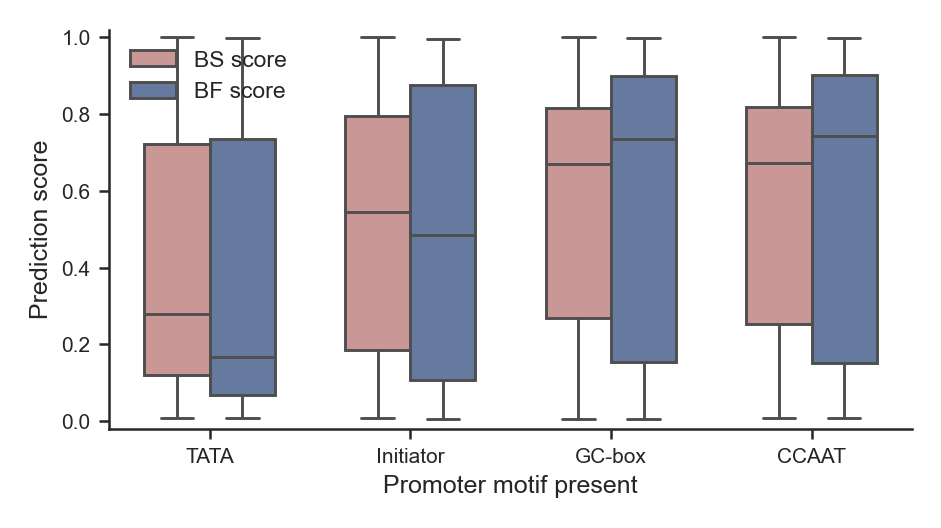

In [66]:

fig, ax = plt.subplots(figsize=(8.0 / 2.54, 4.5 / 2.54))

sns.boxplot(
    data=plot_long,
    x="motif_type",
    y="score",
    hue="score_type",
    showfliers=False,
    linewidth=0.7,
    width=0.65,
    palette={
        "BS score": "#D28E8E",
        "BF score": "#5B78A8",
    },
    ax=ax,
)

# sns.barplot(
#     data=plot_long,
#     x="motif_type",
#     y="score",
#     hue="score_type",
#     linewidth=0.7,
#     width=0.65,
#     palette={
#         "BS score": "#D28E8E",
#         "BF score": "#5B78A8",
#     },
#     ax=ax,
# )
ax.set_xlabel("Promoter motif present")
ax.set_ylabel("Prediction score")
ax.set_ylim(-0.02, 1.02)
ax.set_yticks(np.arange(0, 1.01, 0.2))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(title="", frameon=False)

plt.tight_layout()
plt.show()

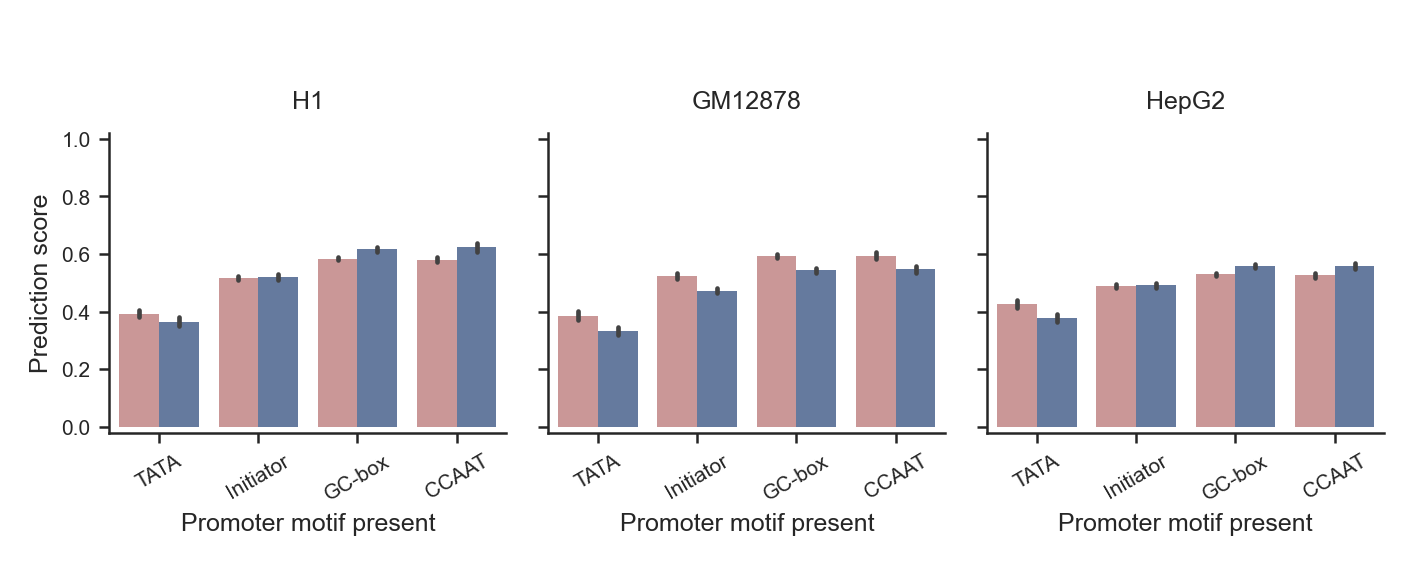

In [67]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(12 / 2.54, 4.3 / 2.54),
    sharey=True
)

palette = {
    "BS score": "#D28E8E",
    "BF score": "#5B78A8",
}

cell_lines = ["H1", "GM12878", "HepG2"]

for ax, cell_line in zip(axes, cell_lines):
    sub = plot_long[plot_long["cell_line"] == cell_line].copy()

    # sns.boxplot(
    #     data=sub,
    #     x="motif_type",
    #     y="score",
    #     hue="score_type",
    #     showfliers=False,
    #     linewidth=0.7,
    #     width=0.65,
    #     palette=palette,
    #     ax=ax,
    # )

    # sns.stripplot(
    #     data=sub,
    #     x="motif_type",
    #     y="score",
    #     hue="score_type",
    #     dodge=True,
    #     jitter=0.18,
    #     size=1.1,
    #     alpha=0.22,
    #     linewidth=0,
    #     palette=palette,
    #     ax=ax,
    #     legend=False,
    # )

    sns.barplot(
        data=sub,
        x="motif_type",
        y="score",
        hue="score_type",
        # alpha=0.22,
        linewidth=0,
        palette=palette,
        ax=ax,
        legend=False,
    )

    ax.set_title(cell_line)
    ax.set_xlabel("Promoter motif present")
    ax.set_ylim(-0.02, 1.02)
    ax.set_yticks(np.arange(0, 1.01, 0.2))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", rotation=30)

    if ax is axes[0]:
        ax.set_ylabel("Prediction score")
    else:
        ax.set_ylabel("")

    if ax.get_legend() is not None:
        ax.get_legend().remove()

# Add one shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles[:2],
    labels[:2],
    title="",
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=2,
)

plt.tight_layout()
plt.show()

In [68]:
data.groupby("eid")[["bs_label_score", "bf_label_score"]].describe()

bs_label_score                                                    \
              count      mean       std       min       25%       50%   
eid                                                                     
E003        14420.0  0.506859  0.292989  0.005285  0.207715  0.645096   
E116        15865.0  0.510574  0.388802  0.006356  0.091237  0.500892   
E118        14307.0  0.491252  0.271574  0.065012  0.222461  0.495297   

                         bf_label_score                                \
           75%       max          count      mean       std       min   
eid                                                                     
E003  0.770156  0.868244        14420.0  0.519902  0.410602  0.006536   
E116  0.919090  0.999947        15865.0  0.471320  0.361547  0.006883   
E118  0.731803  0.998364        14307.0  0.512641  0.342944  0.026487   

                                              
           25%       50%       75%       max  
eid                                           
E003  0.073390  0.560080  0.963305  0.996959  
E116  0.081541  0.427204  0.861457  0.978823  
E118  0.133055  0.570624  0.863514  0.980924

In [69]:
for m in ["tata_label", "initiator_label", "gcbox_label", "ccaat_label"]:

    print(m)

    print(data[data[m] == 1].groupby("eid")["gene_id"].nunique())

tata_label
eid
E003    2180
E116    2316
E118    2052
Name: gene_id, dtype: int64
initiator_label
eid
E003    5766
E116    6238
E118    5949
Name: gene_id, dtype: int64
gcbox_label
eid
E003    7589
E116    8158
E118    7869
Name: gene_id, dtype: int64
ccaat_label
eid
E003    3168
E116    3369
E118    3270
Name: gene_id, dtype: int64


In [49]:
def compute_label_1_ratio(data, group_col, value_col):
    """
    计算 group_col == 1 的 value_col 均值在所有分组均值之和中的占比。

    参数:
    - data: DataFrame，包含需要分析的数据
    - group_col: str，用于分组的列名（例如 'bs_label_label'）
    - value_col: str，要求均值的目标列名（例如 'tata_label'）

    返回:
    - ratio: float，标签为1的分组均值在总均值中所占比例
    """
    grouped = data[[group_col, value_col]].groupby(group_col, as_index=False).mean()
    grouped = grouped.rename(columns={
        group_col: 'Group_Label',
        value_col: 'Value_Mean'
    })

    total_mean = grouped['Value_Mean'].sum()
    label_1_mean = grouped[grouped['Group_Label'] == 1]['Value_Mean'].values[0]
    ratio = label_1_mean / total_mean

    return ratio

In [50]:
bs_ratio = compute_label_1_ratio(data, 'bs_label_pred', 'tata_label')
bf_ratio = compute_label_1_ratio(data, 'bf_label_pred', 'tata_label')
print(f"BS_Label = 1 的占比为: {bs_ratio:.4f}")
print(f"BF_Label = 1 的占比为: {bf_ratio:.4f}")

BS_Label = 1 的占比为: 0.3363
BF_Label = 1 的占比为: 0.3265


In [20]:
bs_ratio = compute_label_1_ratio(data, 'bs_label_label', 'initiator_label')
bf_ratio = compute_label_1_ratio(data, 'bf_label_label', 'initiator_label')
print(f"BS_Label = 1 的占比为: {bs_ratio:.4f}")
print(f"BF_Label = 1 的占比为: {bf_ratio:.4f}")

BS_Label = 1 的占比为: 0.5253
BF_Label = 1 的占比为: 0.5028


In [21]:
bs_ratio = compute_label_1_ratio(data, 'bs_label_label', 'ccaat_label')
bf_ratio = compute_label_1_ratio(data, 'bf_label_label', 'ccaat_label')
print(f"BS_Label = 1 的占比为: {bs_ratio:.4f}")
print(f"BF_Label = 1 的占比为: {bf_ratio:.4f}")

BS_Label = 1 的占比为: 0.5689
BF_Label = 1 的占比为: 0.5838


In [22]:
bs_ratio = compute_label_1_ratio(data, 'bs_label_label', 'gcbox_label')
bf_ratio = compute_label_1_ratio(data, 'bf_label_label', 'gcbox_label')
print(f"BS_Label = 1 的占比为: {bs_ratio:.4f}")
print(f"BF_Label = 1 的占比为: {bf_ratio:.4f}")

BS_Label = 1 的占比为: 0.5629
BF_Label = 1 的占比为: 0.5933


In [51]:
targets = ['bs_label_label','bf_label_label']
motifs = ['tata_label', 'initiator_label', 'ccaat_label', 'gcbox_label']
with open('benchmarks/revised_v2/reviewer1/results/bs_bf_motif_indicators.csv','w') as w:
    line = ['target','motif','ratio']
    w.write(','.join(line) + '\n')      
    for target in targets:
        for motif in motifs:
            ratio = compute_label_1_ratio(data, target, motif)
            line = [target,motif,str(ratio)]
            w.write(','.join(line) + '\n')

<Axes: xlabel='motif', ylabel='ratio'>

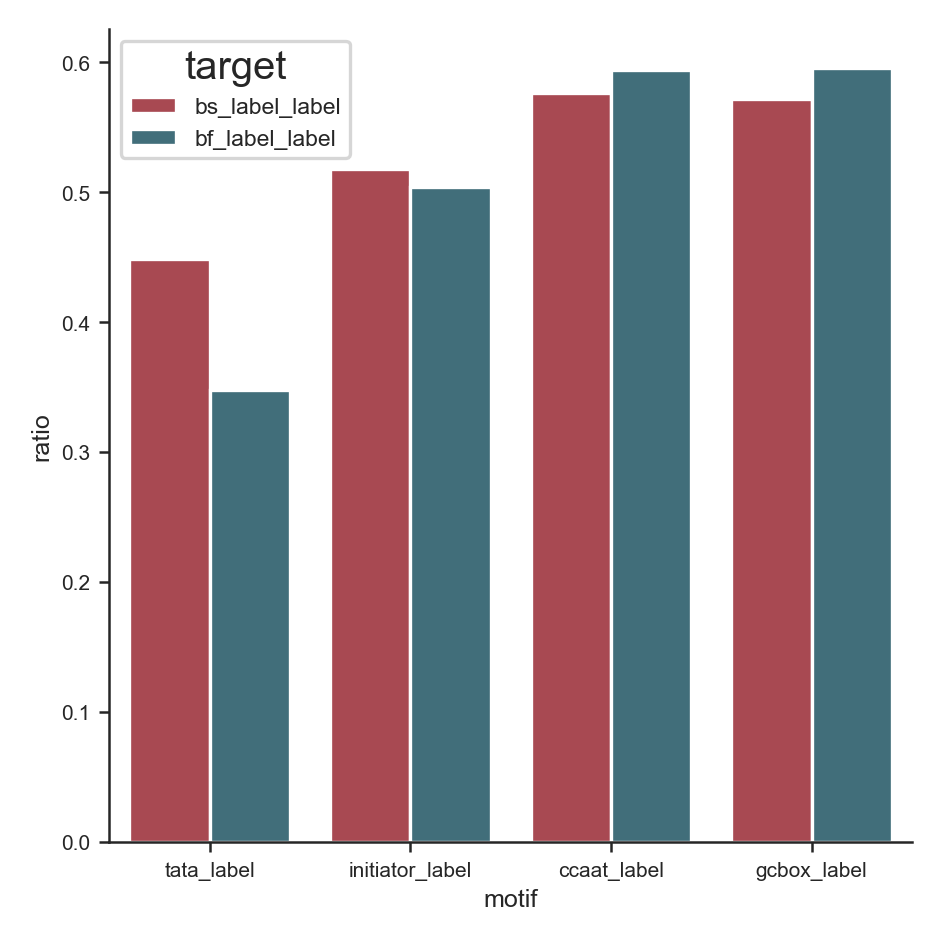

In [52]:
motif_indicatores = pd.read_csv('benchmarks/revised_v2/reviewer1/results/bs_bf_motif_indicators.csv')
motif_indicatores

sns.barplot(data=motif_indicatores,x='motif',y='ratio',hue='target',palette=['#B83945','#377483'])

In [29]:
targets = ['bs_label_pred','bf_label_pred']
motifs = ['tata_label', 'initiator_label', 'ccaat_label', 'gcbox_label']
with open('extra/datasets/benchmark/Promoterformer/results/bs_bf_motif_indicators_pred.csv','w') as w:
    line = ['target','motif','ratio']
    w.write(','.join(line) + '\n')      
    for target in targets:
        for motif in motifs:
            ratio = compute_label_1_ratio(data, target, motif)
            line = [target,motif,str(ratio)]
            w.write(','.join(line) + '\n')

<Axes: xlabel='motif', ylabel='ratio'>

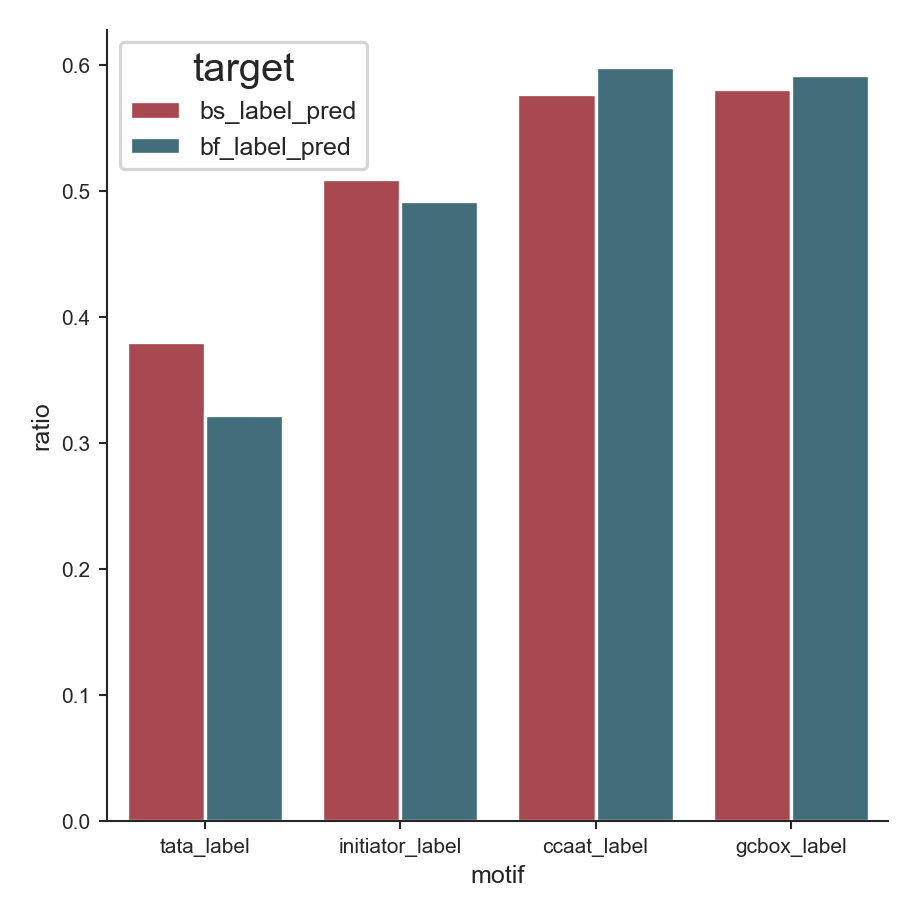

In [30]:
motif_indicatores = pd.read_csv('extra/datasets/benchmark/Promoterformer/results/bs_bf_motif_indicators_pred.csv')
motif_indicatores
sns.barplot(data=motif_indicatores,x='motif',y='ratio',hue='target',palette=['#B83945','#377483'])

In [13]:
data = pd.merge(predictions, motifs, on='gene_id', how='left').fillna(0)
data = data[data['eid']=='E118']
print(data[['bs_label_pred', 'initiator_label']].groupby(['bs_label_pred'],as_index=False).mean())
print(data[['bf_label_pred', 'initiator_label']].groupby(['bf_label_pred'],as_index=False).mean())
data = pd.merge(predictions, motifs, on='gene_id', how='left').fillna(0)
data = data[data['eid']=='E003']
print(data[['bs_label_label', 'initiator_label']].groupby(['bs_label_label'],as_index=False).mean())
print(data[['bf_label_label', 'initiator_label']].groupby(['bf_label_label'],as_index=False).mean())
data = pd.merge(predictions, motifs, on='gene_id', how='left').fillna(0)
data = data[data['eid']=='E116']
print(data[['bs_label_label', 'initiator_label']].groupby(['bs_label_label'],as_index=False).mean())
print(data[['bf_label_label', 'initiator_label']].groupby(['bf_label_label'],as_index=False).mean())

   bs_label_pred  initiator_label
0              0         0.417394
1              1         0.410097
   bf_label_pred  initiator_label
0              0         0.436352
1              1         0.396231
   bs_label_label  initiator_label
0               0         0.383856
1               1         0.417963
   bf_label_label  initiator_label
0               0         0.392681
1               1         0.408455
   bs_label_label  initiator_label
0               0         0.361911
1               1         0.415810
   bf_label_label  initiator_label
0               0         0.380638
1               1         0.397631


In [86]:
data = pd.merge(predictions, motifs, on='gene_id', how='left').fillna(0)
data = data[data['eid']=='E118']
print(data[['bs_label_label', 'ccaat_label']].groupby(['bs_label_label'],as_index=False).mean())
print(data[['bf_label_label', 'ccaat_label']].groupby(['bf_label_label'],as_index=False).mean())
data = pd.merge(predictions, motifs, on='gene_id', how='left').fillna(0)
data = data[data['eid']=='E003']
print(data[['bs_label_label', 'ccaat_label']].groupby(['bs_label_label'],as_index=False).mean())
print(data[['bf_label_label', 'ccaat_label']].groupby(['bf_label_label'],as_index=False).mean())
data = pd.merge(predictions, motifs, on='gene_id', how='left').fillna(0)
data = data[data['eid']=='E116']
print(data[['bs_label_label', 'ccaat_label']].groupby(['bs_label_label'],as_index=False).mean())
print(data[['bf_label_label', 'ccaat_label']].groupby(['bf_label_label'],as_index=False).mean())

   bs_label_label  ccaat_label
0               0     0.211671
1               1     0.252937
   bf_label_label  ccaat_label
0               0     0.205764
1               1     0.255973
   bs_label_label  ccaat_label
0               0     0.188708
1               1     0.252067
   bf_label_label  ccaat_label
0               0     0.170411
1               1     0.267772
   bs_label_label  ccaat_label
0               0     0.176309
1               1     0.254370
   bf_label_label  ccaat_label
0               0     0.178881
1               1     0.252766


In [87]:
data = pd.merge(predictions, motifs, on='gene_id', how='left').fillna(0)
data = data[data['eid']=='E118']
print(data[['bs_label_label', 'gcbox_label']].groupby(['bs_label_label'],as_index=False).mean())
print(data[['bf_label_label', 'gcbox_label']].groupby(['bf_label_label'],as_index=False).mean())
data = pd.merge(predictions, motifs, on='gene_id', how='left').fillna(0)
data = data[data['eid']=='E003']
print(data[['bs_label_label', 'gcbox_label']].groupby(['bs_label_label'],as_index=False).mean())
print(data[['bf_label_label', 'gcbox_label']].groupby(['bf_label_label'],as_index=False).mean())
data = pd.merge(predictions, motifs, on='gene_id', how='left').fillna(0)
data = data[data['eid']=='E116']
print(data[['bs_label_label', 'gcbox_label']].groupby(['bs_label_label'],as_index=False).mean())
print(data[['bf_label_label', 'gcbox_label']].groupby(['bf_label_label'],as_index=False).mean())

   bs_label_label  gcbox_label
0               0     0.514378
1               1     0.589294
   bf_label_label  gcbox_label
0               0     0.470061
1               1     0.626240
   bs_label_label  gcbox_label
0               0     0.452241
1               1     0.601373
   bf_label_label  gcbox_label
0               0     0.407517
1               1     0.639935
   bs_label_label  gcbox_label
0               0     0.426702
1               1     0.599229
   bf_label_label  gcbox_label
0               0     0.414372
1               1     0.613823


[INFO] predictions: (44592, 9)
           gene_id  bs_label_label  bs_label_score  bs_label_pred  \
0  ENSG00000132470               1        0.087409              0   
1  ENSG00000197446               0        0.020184              0   
2  ENSG00000136110               0        0.069456              0   
3  ENSG00000105576               1        0.979691              1   
4  ENSG00000136872               0        0.042485              0   

   bf_label_label  bf_label_score  bf_label_pred  fold   eid  
0               0        0.137287              0     0  E116  
1               0        0.028083              0     0  E116  
2               0        0.088738              0     0  E116  
3               1        0.834360              1     0  E116  
4               0        0.048272              0     0  E116  
[INFO] motifs: (244981, 5)
           gene_id  tata_label  initiator_label  ccaat_label  gcbox_label
0  ENSG00000188290           1                0            1            1
1

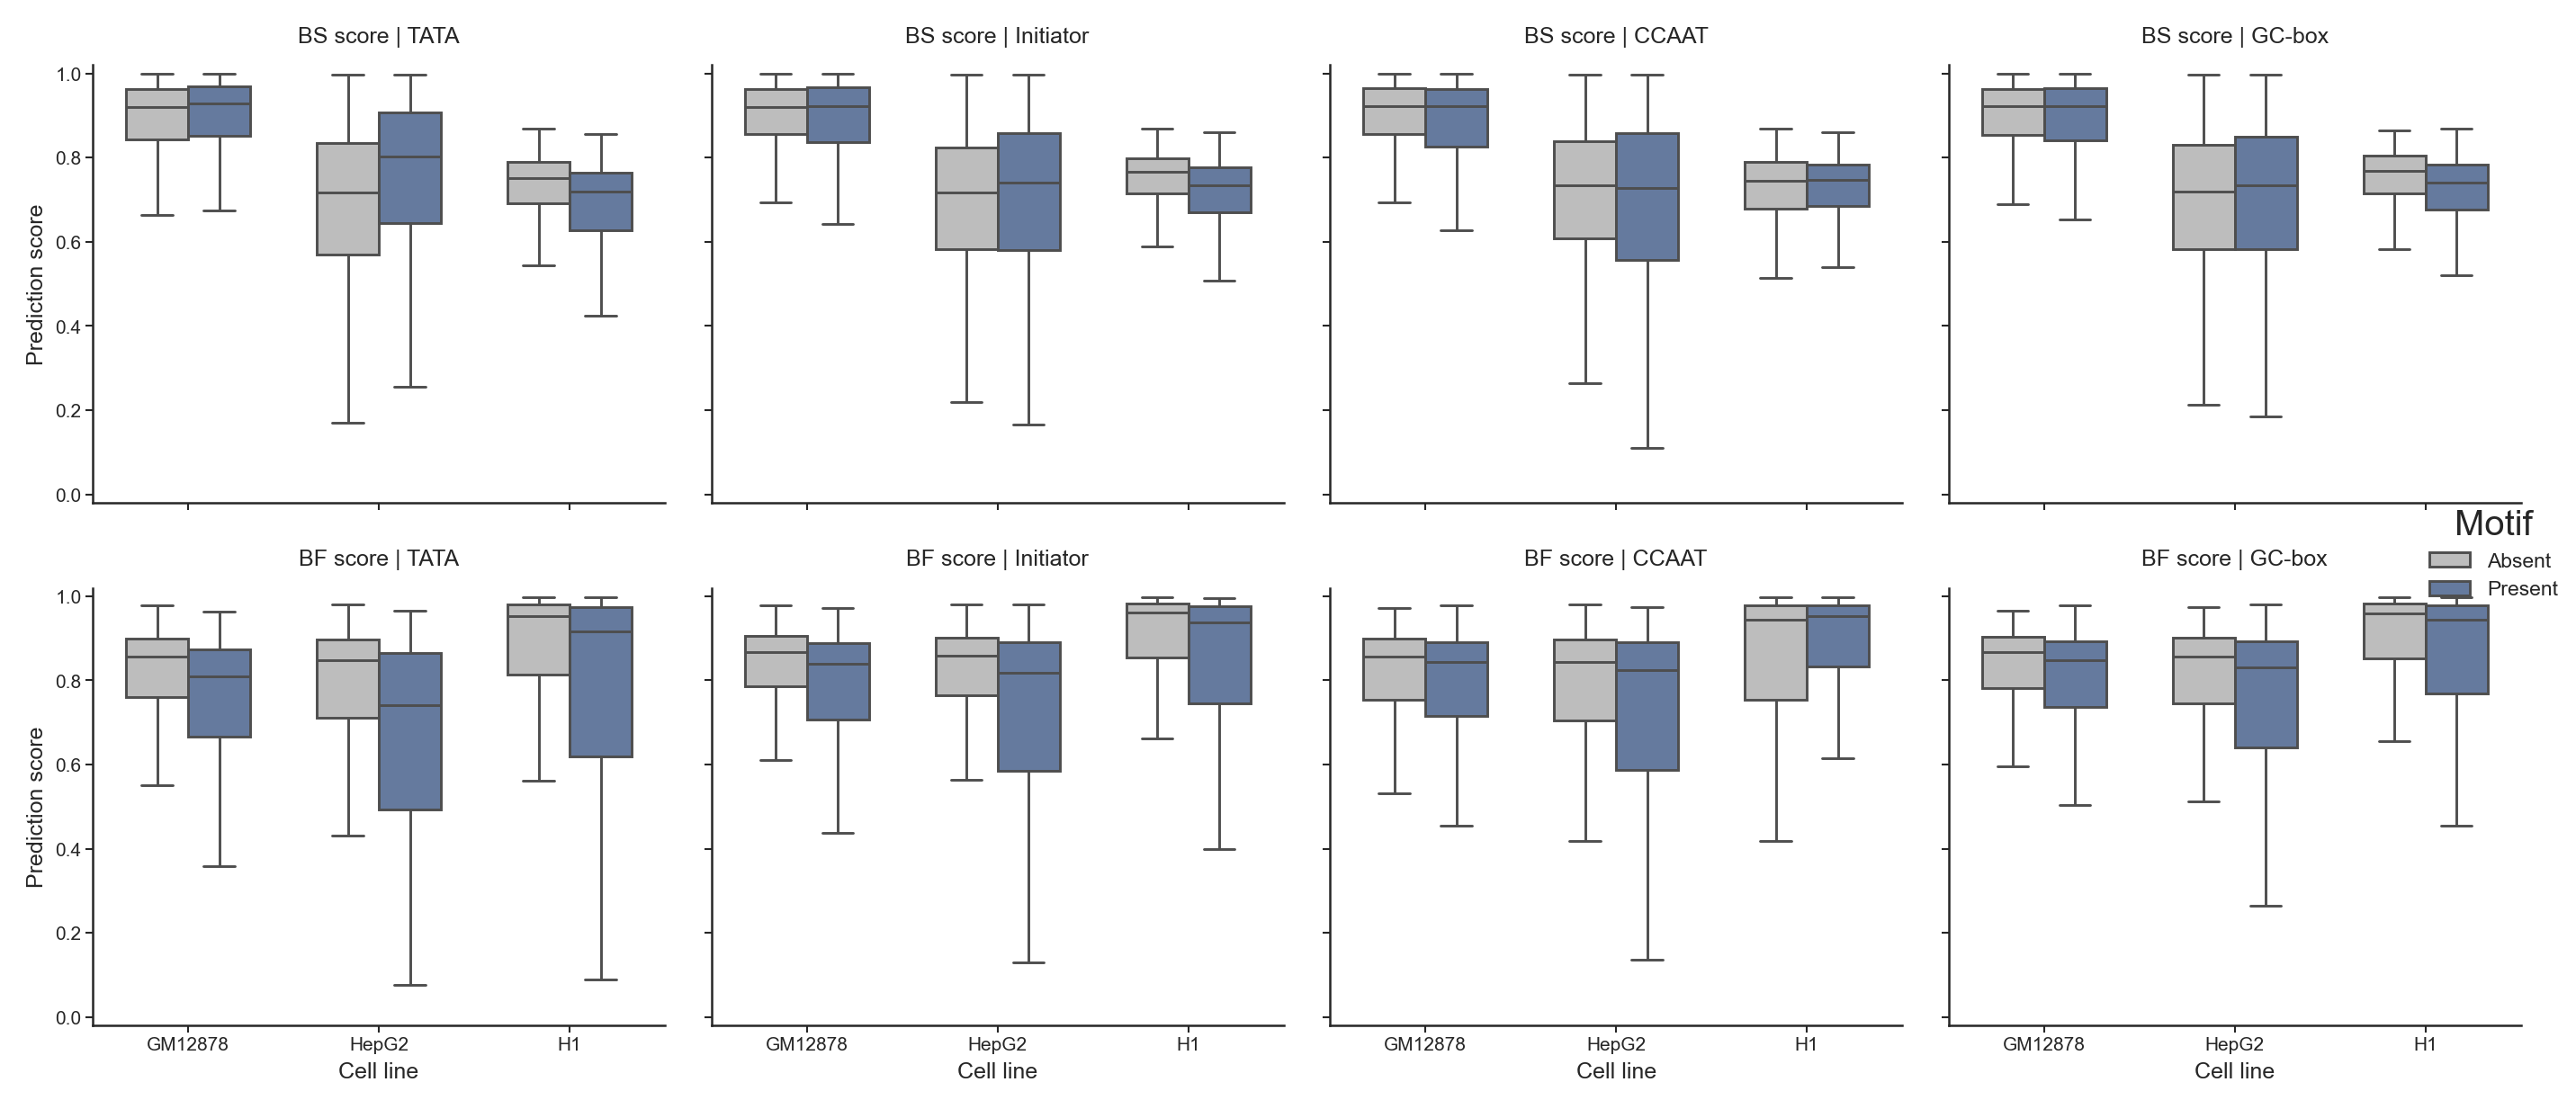

   cell_line motif_type motif_label  n_genes
0    GM12878       TATA      Absent     6876
1    GM12878       TATA     Present      743
2    GM12878  Initiator      Absent     4552
3    GM12878  Initiator     Present     3067
4    GM12878      CCAAT      Absent     5621
5    GM12878      CCAAT     Present     1998
6    GM12878     GC-box      Absent     2851
7    GM12878     GC-box     Present     4768
8      HepG2       TATA      Absent     6435
9      HepG2       TATA     Present      782
10     HepG2  Initiator      Absent     4272
11     HepG2  Initiator     Present     2945
12     HepG2      CCAAT      Absent     5303
13     HepG2      CCAAT     Present     1914
14     HepG2     GC-box      Absent     2655
15     HepG2     GC-box     Present     4562
16        H1       TATA      Absent     6704
17        H1       TATA     Present      808
18        H1  Initiator      Absent     4427
19        H1  Initiator     Present     3085
20        H1      CCAAT      Absent     5462
21        

,eid,cell_line,score_type,motif_type,n_absent,n_present,median_absent,median_present,delta_median_present_minus_absent,rank_sum_stat,p_value,fdr
0,E116,GM12878,BS score,TATA,16108,3859,0.919925,0.929522,0.009597,4.503319,6.690050e-06,8.450589e-06
1,E116,GM12878,BS score,Initiator,7107,12860,0.920023,0.923140,0.003117,-0.003177,9.974650e-01,9.974650e-01
2,E116,GM12878,BS score,CCAAT,11029,8938,0.922031,0.921813,-0.000218,-4.890708,1.004737e-06,1.339649e-06
3,E116,GM12878,BS score,GC-box,3426,16541,0.921961,0.922031,0.000070,-1.126689,2.598739e-01,2.834988e-01
4,E116,GM12878,BF score,TATA,16108,3859,0.857255,0.810128,-0.047127,-18.948771,4.520130e-80,1.549759e-79
5,E116,GM12878,BF score,Initiator,7107,12860,0.867804,0.838715,-0.029089,-22.393721,4.531334e-111,2.718801e-110
6,E116,GM12878,BF score,CCAAT,11029,8938,0.856465,0.842914,-0.013551,-10.378547,3.104656e-25,6.209313e-25
7,E116,GM12878,BF score,GC-box,3426,16541,0.866506,0.847650,-0.018856,-10.867930,1.638770e-27,3.575499e-27
8,E118,HepG2,BS score,TATA,15601,4082,0.717433,0.803337,0.085904,18.669149,8.824806e-78,2.647442e-77
9,E118,HepG2,BS score,Initiator,6530,13153,0.716326,0.741698,0.025372,7.343622,2.078891e-13,3.118337e-13


In [5]:
# ============================================================
# Plot BS/BF prediction scores by promoter motif labels
# Restricted to expressed genes in each cell type
# ============================================================

import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. Input paths
# ============================================================

prediction_path = Path("./extra/results/predictions_bs_bf.csv")
# prediction_path = Path("./extra/results/predictions_bs_bf_deeptx.csv")


motif_path = Path(
    "./benchmarks/revised_v2/reviewer1/results/gene_ids_with_labels.bed"
)

meta_dir = Path("./extra/datasets/processed/v2/meta_datasets")

# output_dir = Path("./benchmarks/revised_v2/reviewer1/figures")
# output_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. Basic settings
# ============================================================

eid_list = ["E116", "E118", "E003"]

eid_name_map = {
    "E116": "GM12878",
    "E118": "HepG2",
    "E003": "H1",
}

score_cols = ["bs_label_score", "bf_label_score"]

motif_cols = [
    "tata_label",
    "initiator_label",
    "ccaat_label",
    "gcbox_label",
]

motif_name_map = {
    "tata_label": "TATA",
    "initiator_label": "Initiator",
    "ccaat_label": "CCAAT",
    "gcbox_label": "GC-box",
}

score_name_map = {
    "bs_label_score": "BS score",
    "bf_label_score": "BF score",
}


# ============================================================
# 3. Load prediction results
# ============================================================

predictions = pd.read_csv(prediction_path)

required_pred_cols = [
    "gene_id",
    "eid",
    "bs_label_score",
    "bf_label_score",
]

missing_pred_cols = [
    c for c in required_pred_cols if c not in predictions.columns
]

if missing_pred_cols:
    raise ValueError(f"Missing columns in prediction file: {missing_pred_cols}")

print("[INFO] predictions:", predictions.shape)
print(predictions.head())


# ============================================================
# 4. Load motif labels
# ============================================================

motifs = pd.read_csv(
    motif_path,
    sep="\t",
    usecols=["gene_id"] + motif_cols,
)

motifs[motif_cols] = motifs[motif_cols].fillna(0).astype(int)

print("[INFO] motifs:", motifs.shape)
print(motifs.head())


# ============================================================
# 5. Merge predictions with motif labels
# ============================================================

data = pd.merge(
    predictions,
    motifs,
    on="gene_id",
    how="left",
)

data[motif_cols] = data[motif_cols].fillna(0).astype(int)

print("[INFO] merged data:", data.shape)
print(data.head())


# ============================================================
# 6. Load meta_data_{eid}.csv and keep expressed genes
# ============================================================

meta_list = []

for eid in eid_list:
    meta_path = meta_dir / f"meta_data_{eid}.csv"

    if not meta_path.exists():
        raise FileNotFoundError(f"Cannot find meta file: {meta_path}")

    meta = pd.read_csv(
        meta_path,
        usecols=[
            "gene_id",
            "eid",
            "expression",
            "bulk_exp",
            "sc_exp_label",
            "bulk_exp_label",
            "mean_label",
        ],
    )

    meta_list.append(meta)

meta_df = pd.concat(meta_list, ignore_index=True)

print("[INFO] meta data:", meta_df.shape)
print(meta_df.head())


# ============================================================
# 7. Filter expressed genes
# ============================================================
# 推荐使用 sc_exp_label == 1，因为 BF/BS labels 来自单细胞动力学推断流程。
# 如果想改用 bulk 表达过滤，把 filter_col 改成 "bulk_exp_label"。

filter_col = "mean_label"

expressed_df = (
    meta_df[meta_df[filter_col] == 1][["gene_id", "eid"]]
    .drop_duplicates()
    .copy()
)

data_expr = data.merge(
    expressed_df.assign(is_expressed=1),
    on=["gene_id", "eid"],
    how="left",
)

data_expr = data_expr[data_expr["is_expressed"] == 1].copy()

print("[INFO] original merged data:", data.shape)
print("[INFO] expressed-gene filtered data:", data_expr.shape)

print(
    data_expr.groupby("eid")["gene_id"]
    .nunique()
    .rename("n_expressed_genes")
)


# ============================================================
# 8. Convert to long format for plotting
# ============================================================

plot_df = data_expr.melt(
    id_vars=["gene_id", "eid"] + motif_cols,
    value_vars=score_cols,
    var_name="score_type",
    value_name="score",
)

plot_df["score_type"] = plot_df["score_type"].map(score_name_map)

plot_long = plot_df.melt(
    id_vars=["gene_id", "eid", "score_type", "score"],
    value_vars=motif_cols,
    var_name="motif_type",
    value_name="motif_label",
)

plot_long["motif_type"] = plot_long["motif_type"].map(motif_name_map)

plot_long["motif_label"] = (
    plot_long["motif_label"]
    .fillna(0)
    .astype(int)
    .map({0: "Absent", 1: "Present"})
)

plot_long["cell_line"] = plot_long["eid"].map(eid_name_map)

# 控制显示顺序
plot_long["eid"] = pd.Categorical(
    plot_long["eid"],
    categories=eid_list,
    ordered=True,
)

plot_long["cell_line"] = pd.Categorical(
    plot_long["cell_line"],
    categories=[eid_name_map[eid] for eid in eid_list],
    ordered=True,
)

plot_long["score_type"] = pd.Categorical(
    plot_long["score_type"],
    categories=["BS score", "BF score"],
    ordered=True,
)

plot_long["motif_type"] = pd.Categorical(
    plot_long["motif_type"],
    categories=["TATA", "Initiator", "CCAAT", "GC-box"],
    ordered=True,
)

plot_long["motif_label"] = pd.Categorical(
    plot_long["motif_label"],
    categories=["Absent", "Present"],
    ordered=True,
)

print("[INFO] plot_long:", plot_long.shape)
print(plot_long.head())


# ============================================================
# 9. Nature-style plotting parameters
# ============================================================

palette = {
    "Absent": "#BDBDBD",
    "Present": "#5B78A8",
}


# ============================================================
# 10. Plot all motifs and both scores in one figure
# ============================================================

g = sns.catplot(
    data=plot_long,
    x="cell_line",
    y="score",
    hue="motif_label",
    row="score_type",
    col="motif_type",
    kind="box",
    height=2.1,
    aspect=1.05,
    showfliers=False,
    linewidth=0.7,
    width=0.65,
    palette=palette,
    sharey=True,
)

g.set_axis_labels("Cell line", "Prediction score")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

for ax in g.axes.flat:
    ax.set_ylim(-0.02, 1.02)
    ax.set_yticks(np.arange(0, 1.01, 0.2))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.6)
    ax.spines["bottom"].set_linewidth(0.6)

    ax.tick_params(axis="x", rotation=0, pad=1)
    ax.tick_params(axis="y", pad=1)

if g._legend is not None:
    g._legend.set_title("Motif")
    g._legend.set_frame_on(False)

plt.tight_layout()

# pdf_path = output_dir / "motif_label_bs_bf_score_expressed_genes_boxplot.pdf"
# eps_path = output_dir / "motif_label_bs_bf_score_expressed_genes_boxplot.eps"
# png_path = output_dir / "motif_label_bs_bf_score_expressed_genes_boxplot.png"

# g.savefig(pdf_path, bbox_inches="tight")
# g.savefig(eps_path, bbox_inches="tight")
# g.savefig(png_path, dpi=300, bbox_inches="tight")

plt.show()

# print(f"[INFO] Saved: {pdf_path}")
# print(f"[INFO] Saved: {eps_path}")
# print(f"[INFO] Saved: {png_path}")


# ============================================================
# 11. Optional: sample size table
# ============================================================

sample_size = (
    plot_long
    .drop_duplicates(["gene_id", "eid", "motif_type", "motif_label"])
    .groupby(["cell_line", "motif_type", "motif_label"], observed=False)
    .size()
    .reset_index(name="n_genes")
)

print(sample_size)


# ============================================================
# 12. Optional: Wilcoxon rank-sum test
# ============================================================

from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests

stat_rows = []

for (eid, score_type, motif_type), sub in plot_long.groupby(
    ["eid", "score_type", "motif_type"],
    observed=False,
):
    absent = sub[sub["motif_label"] == "Absent"]["score"].dropna()
    present = sub[sub["motif_label"] == "Present"]["score"].dropna()

    if len(absent) < 5 or len(present) < 5:
        continue

    stat, pval = ranksums(present, absent)

    stat_rows.append({
        "eid": eid,
        "cell_line": eid_name_map[str(eid)],
        "score_type": score_type,
        "motif_type": motif_type,
        "n_absent": len(absent),
        "n_present": len(present),
        "median_absent": absent.median(),
        "median_present": present.median(),
        "delta_median_present_minus_absent": present.median() - absent.median(),
        "rank_sum_stat": stat,
        "p_value": pval,
    })

stat_df = pd.DataFrame(stat_rows)

if len(stat_df) > 0:
    stat_df["fdr"] = multipletests(
        stat_df["p_value"],
        method="fdr_bh",
    )[1]

# stat_path = output_dir / "motif_label_bs_bf_score_expressed_genes_stats.csv"
# stat_df.to_csv(stat_path, index=False)

# print(f"[INFO] Saved statistics: {stat_path}")
stat_df

[INFO] predictions: (43708, 9)
           gene_id  bs_label_label  bs_label_score  bs_label_pred  \
0  ENSG00000169184               0        0.270725              0   
1  ENSG00000141293               1        0.764903              1   
2  ENSG00000171396               0        0.188031              0   
3  ENSG00000108433               1        0.862104              1   
4  ENSG00000204379               0        0.111213              0   

   bf_label_label  bf_label_score  bf_label_pred  fold   eid  
0               0        0.007134              0     0  E116  
1               1        0.967702              1     0  E116  
2               0        0.005056              0     0  E116  
3               1        0.979269              1     0  E116  
4               0        0.026535              0     0  E116  
[INFO] motifs: (244981, 5)
           gene_id  tata_label  initiator_label  ccaat_label  gcbox_label
0  ENSG00000188290           1                0            1            1
1

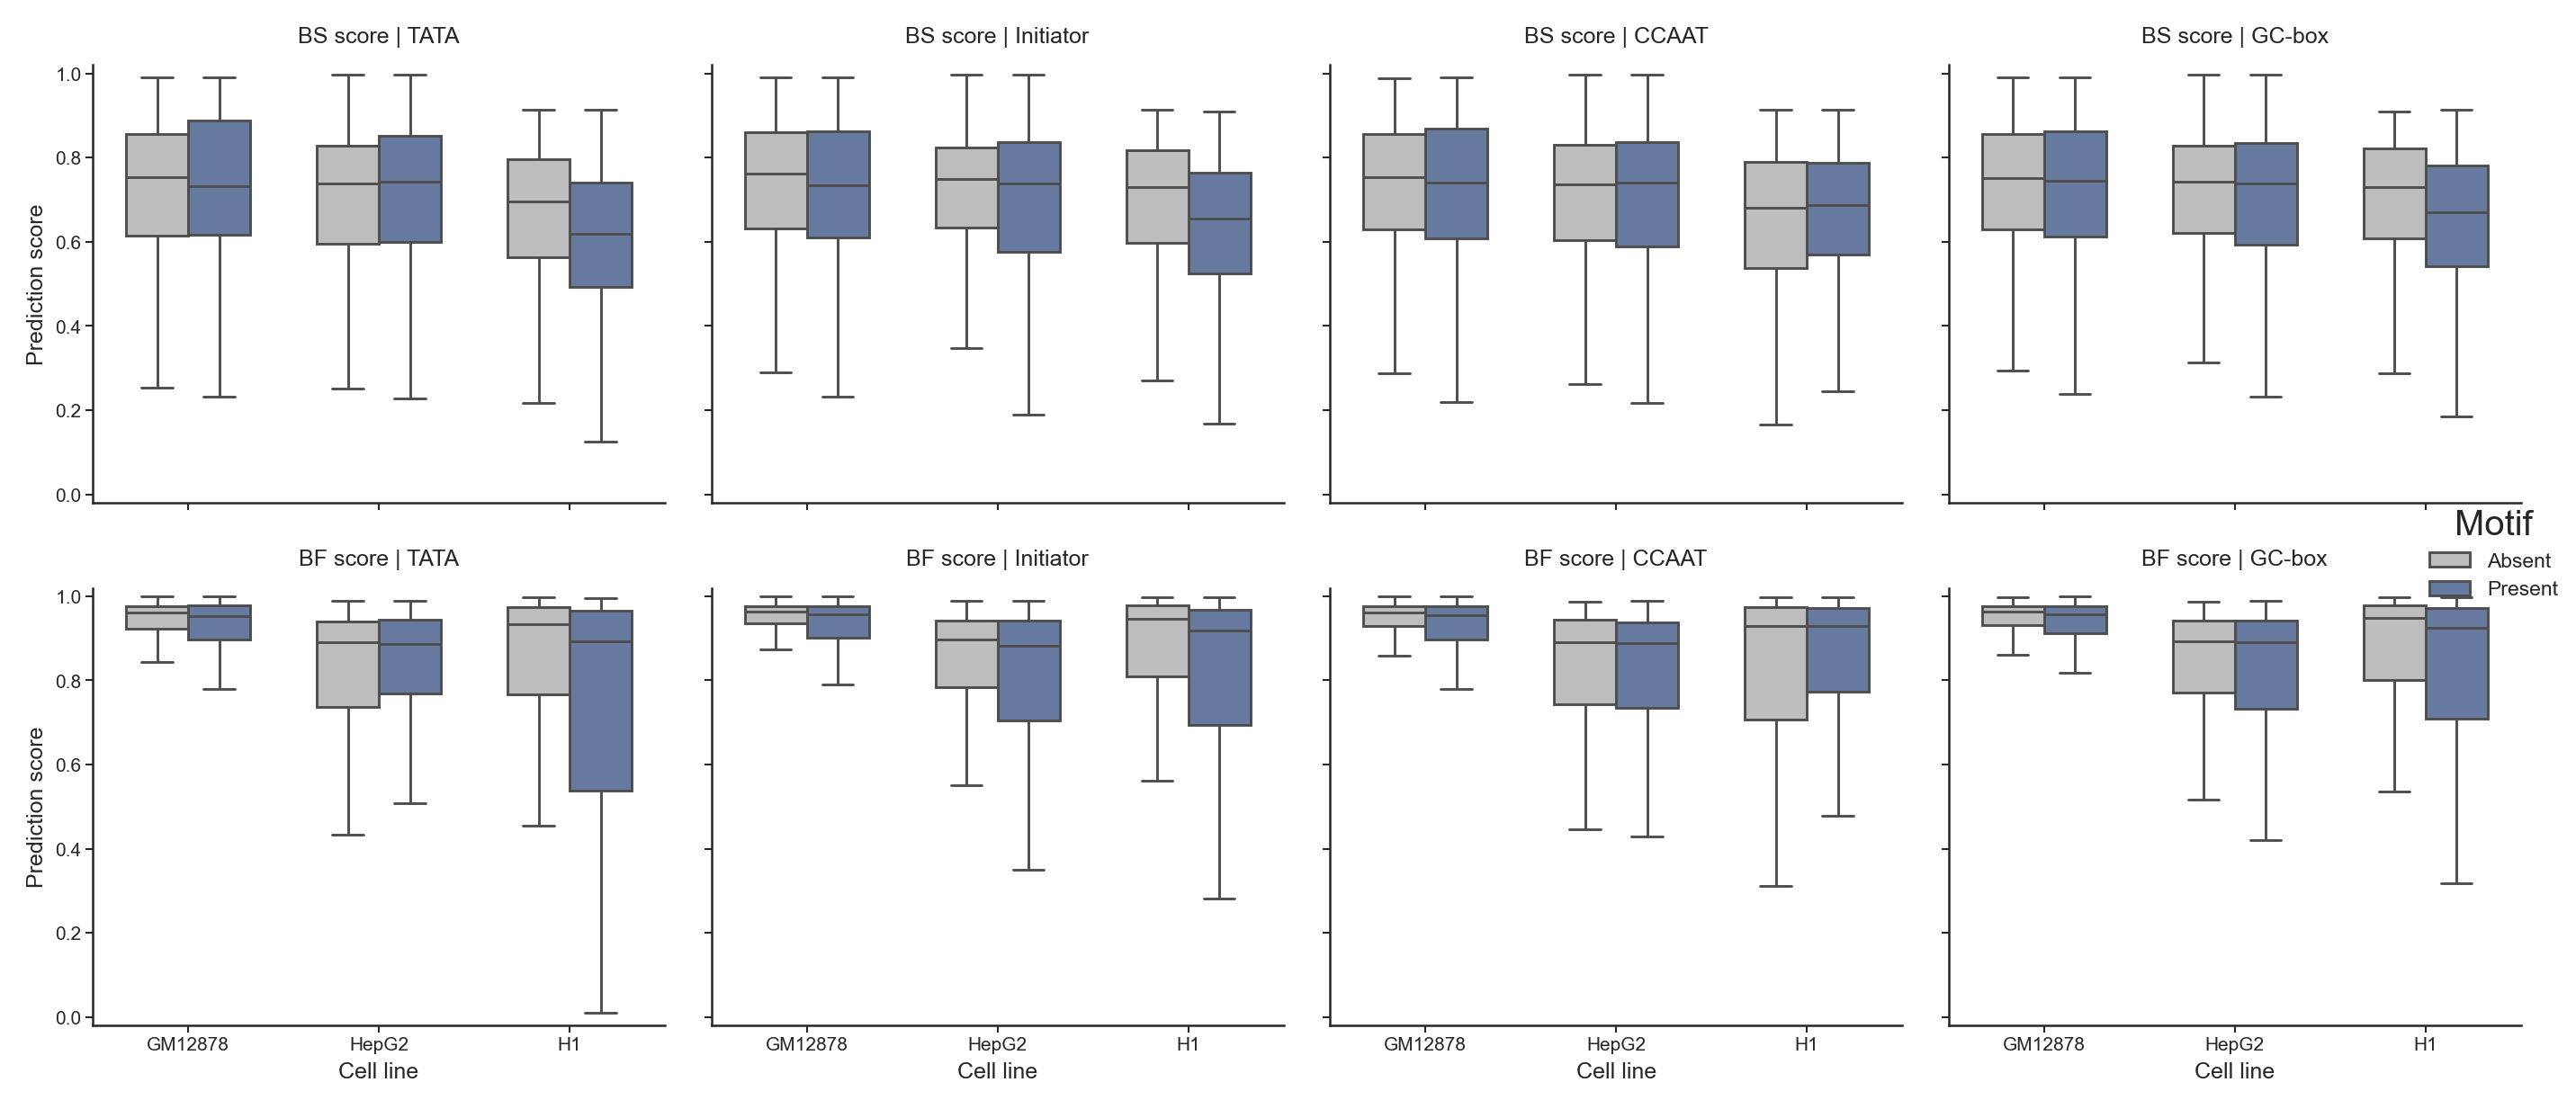

   cell_line motif_type motif_label  n_genes
0    GM12878       TATA      Absent     6710
1    GM12878       TATA     Present      726
2    GM12878  Initiator      Absent     4441
3    GM12878  Initiator     Present     2995
4    GM12878      CCAAT      Absent     5485
5    GM12878      CCAAT     Present     1951
6    GM12878     GC-box      Absent     2784
7    GM12878     GC-box     Present     4652
8      HepG2       TATA      Absent     6384
9      HepG2       TATA     Present      777
10     HepG2  Initiator      Absent     4239
11     HepG2  Initiator     Present     2922
12     HepG2      CCAAT      Absent     5259
13     HepG2      CCAAT     Present     1902
14     HepG2     GC-box      Absent     2636
15     HepG2     GC-box     Present     4525
16        H1       TATA      Absent     6659
17        H1       TATA     Present      805
18        H1  Initiator      Absent     4403
19        H1  Initiator     Present     3061
20        H1      CCAAT      Absent     5426
21        

,eid,cell_line,score_type,motif_type,n_absent,n_present,median_absent,median_present,delta_median_present_minus_absent,rank_sum_stat,p_value,fdr
0,E116,GM12878,BS score,TATA,15683,3784,0.753181,0.733133,-0.020048,-0.831793,4.055259e-01,4.231574e-01
1,E116,GM12878,BS score,Initiator,6954,12513,0.762213,0.733519,-0.028694,-5.967663,2.406756e-09,4.443242e-09
2,E116,GM12878,BS score,CCAAT,10782,8685,0.752902,0.740058,-0.012844,-4.345919,1.386939e-05,2.377609e-05
3,E116,GM12878,BS score,GC-box,3341,16126,0.752580,0.746169,-0.006411,-1.197105,2.312656e-01,2.522898e-01
4,E116,GM12878,BF score,TATA,15683,3784,0.960520,0.953782,-0.006737,-7.749522,9.223936e-15,2.213745e-14
5,E116,GM12878,BF score,Initiator,6954,12513,0.964496,0.956472,-0.008024,-13.985829,1.902479e-44,7.609915e-44
6,E116,GM12878,BF score,CCAAT,10782,8685,0.961657,0.955934,-0.005723,-9.234292,2.600004e-20,7.800011e-20
7,E116,GM12878,BF score,GC-box,3341,16126,0.963709,0.958045,-0.005664,-6.856028,7.080135e-12,1.544757e-11
8,E118,HepG2,BS score,TATA,15515,4066,0.738864,0.742584,0.003719,6.125296,9.051528e-10,1.810306e-09
9,E118,HepG2,BS score,Initiator,6488,13093,0.749018,0.738883,-0.010135,-4.246119,2.175049e-05,3.480079e-05


In [ ]:
# ============================================================
# Plot BS/BF prediction scores by promoter motif labels
# Restricted to expressed genes in each cell type
# ============================================================

import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. Input paths
# ============================================================

# prediction_path = Path("./extra/results/predictions_bs_bf.csv")
prediction_path = Path("./extra/results/predictions_bs_bf_deeptx.csv")


motif_path = Path(
    "./benchmarks/revised_v2/reviewer1/results/gene_ids_with_labels.bed"
)

meta_dir = Path("./extra/datasets/processed/v2/meta_datasets")

# output_dir = Path("./benchmarks/revised_v2/reviewer1/figures")
# output_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. Basic settings
# ============================================================

eid_list = ["E116", "E118", "E003"]

eid_name_map = {
    "E116": "GM12878",
    "E118": "HepG2",
    "E003": "H1",
}

score_cols = ["bs_label_score", "bf_label_score"]

motif_cols = [
    "tata_label",
    "initiator_label",
    "ccaat_label",
    "gcbox_label",
]

motif_name_map = {
    "tata_label": "TATA",
    "initiator_label": "Initiator",
    "ccaat_label": "CCAAT",
    "gcbox_label": "GC-box",
}

score_name_map = {
    "bs_label_score": "BS score",
    "bf_label_score": "BF score",
}


# ============================================================
# 3. Load prediction results
# ============================================================

predictions = pd.read_csv(prediction_path)

required_pred_cols = [
    "gene_id",
    "eid",
    "bs_label_score",
    "bf_label_score",
]

missing_pred_cols = [
    c for c in required_pred_cols if c not in predictions.columns
]

if missing_pred_cols:
    raise ValueError(f"Missing columns in prediction file: {missing_pred_cols}")

print("[INFO] predictions:", predictions.shape)
print(predictions.head())


# ============================================================
# 4. Load motif labels
# ============================================================

motifs = pd.read_csv(
    motif_path,
    sep="\t",
    usecols=["gene_id"] + motif_cols,
)

motifs[motif_cols] = motifs[motif_cols].fillna(0).astype(int)

print("[INFO] motifs:", motifs.shape)
print(motifs.head())


# ============================================================
# 5. Merge predictions with motif labels
# ============================================================

data = pd.merge(
    predictions,
    motifs,
    on="gene_id",
    how="left",
)

data[motif_cols] = data[motif_cols].fillna(0).astype(int)

print("[INFO] merged data:", data.shape)
print(data.head())


# ============================================================
# 6. Load meta_data_{eid}.csv and keep expressed genes
# ============================================================

meta_list = []

for eid in eid_list:
    meta_path = meta_dir / f"meta_data_{eid}.csv"

    if not meta_path.exists():
        raise FileNotFoundError(f"Cannot find meta file: {meta_path}")

    meta = pd.read_csv(
        meta_path,
        usecols=[
            "gene_id",
            "eid",
            "expression",
            "bulk_exp",
            "sc_exp_label",
            "bulk_exp_label",
            "mean_label",
        ],
    )

    meta_list.append(meta)

meta_df = pd.concat(meta_list, ignore_index=True)

print("[INFO] meta data:", meta_df.shape)
print(meta_df.head())


# ============================================================
# 7. Filter expressed genes
# ============================================================
# 推荐使用 sc_exp_label == 1，因为 BF/BS labels 来自单细胞动力学推断流程。
# 如果想改用 bulk 表达过滤，把 filter_col 改成 "bulk_exp_label"。

filter_col = "mean_label"

expressed_df = (
    meta_df[meta_df[filter_col] == 1][["gene_id", "eid"]]
    .drop_duplicates()
    .copy()
)

data_expr = data.merge(
    expressed_df.assign(is_expressed=1),
    on=["gene_id", "eid"],
    how="left",
)

data_expr = data_expr[data_expr["is_expressed"] == 1].copy()

print("[INFO] original merged data:", data.shape)
print("[INFO] expressed-gene filtered data:", data_expr.shape)

print(
    data_expr.groupby("eid")["gene_id"]
    .nunique()
    .rename("n_expressed_genes")
)


# ============================================================
# 8. Convert to long format for plotting
# ============================================================

plot_df = data_expr.melt(
    id_vars=["gene_id", "eid"] + motif_cols,
    value_vars=score_cols,
    var_name="score_type",
    value_name="score",
)

plot_df["score_type"] = plot_df["score_type"].map(score_name_map)

plot_long = plot_df.melt(
    id_vars=["gene_id", "eid", "score_type", "score"],
    value_vars=motif_cols,
    var_name="motif_type",
    value_name="motif_label",
)

plot_long["motif_type"] = plot_long["motif_type"].map(motif_name_map)

plot_long["motif_label"] = (
    plot_long["motif_label"]
    .fillna(0)
    .astype(int)
    .map({0: "Absent", 1: "Present"})
)

plot_long["cell_line"] = plot_long["eid"].map(eid_name_map)

# 控制显示顺序
plot_long["eid"] = pd.Categorical(
    plot_long["eid"],
    categories=eid_list,
    ordered=True,
)

plot_long["cell_line"] = pd.Categorical(
    plot_long["cell_line"],
    categories=[eid_name_map[eid] for eid in eid_list],
    ordered=True,
)

plot_long["score_type"] = pd.Categorical(
    plot_long["score_type"],
    categories=["BS score", "BF score"],
    ordered=True,
)

plot_long["motif_type"] = pd.Categorical(
    plot_long["motif_type"],
    categories=["TATA", "Initiator", "CCAAT", "GC-box"],
    ordered=True,
)

plot_long["motif_label"] = pd.Categorical(
    plot_long["motif_label"],
    categories=["Absent", "Present"],
    ordered=True,
)

print("[INFO] plot_long:", plot_long.shape)
print(plot_long.head())


# ============================================================
# 9. Nature-style plotting parameters
# ============================================================

palette = {
    "Absent": "#BDBDBD",
    "Present": "#5B78A8",
}


# ============================================================
# 10. Plot all motifs and both scores in one figure
# ============================================================

g = sns.catplot(
    data=plot_long,
    x="cell_line",
    y="score",
    hue="motif_label",
    row="score_type",
    col="motif_type",
    kind="box",
    height=2.1,
    aspect=1.05,
    showfliers=False,
    linewidth=0.7,
    width=0.65,
    palette=palette,
    sharey=True,
)

g.set_axis_labels("Cell line", "Prediction score")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

for ax in g.axes.flat:
    ax.set_ylim(-0.02, 1.02)
    ax.set_yticks(np.arange(0, 1.01, 0.2))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.6)
    ax.spines["bottom"].set_linewidth(0.6)

    ax.tick_params(axis="x", rotation=0, pad=1)
    ax.tick_params(axis="y", pad=1)

if g._legend is not None:
    g._legend.set_title("Motif")
    g._legend.set_frame_on(False)

plt.tight_layout()

# pdf_path = output_dir / "motif_label_bs_bf_score_expressed_genes_boxplot.pdf"
# eps_path = output_dir / "motif_label_bs_bf_score_expressed_genes_boxplot.eps"
# png_path = output_dir / "motif_label_bs_bf_score_expressed_genes_boxplot.png"

# g.savefig(pdf_path, bbox_inches="tight")
# g.savefig(eps_path, bbox_inches="tight")
# g.savefig(png_path, dpi=300, bbox_inches="tight")

plt.show()

# print(f"[INFO] Saved: {pdf_path}")
# print(f"[INFO] Saved: {eps_path}")
# print(f"[INFO] Saved: {png_path}")


# ============================================================
# 11. Optional: sample size table
# ============================================================

sample_size = (
    plot_long
    .drop_duplicates(["gene_id", "eid", "motif_type", "motif_label"])
    .groupby(["cell_line", "motif_type", "motif_label"], observed=False)
    .size()
    .reset_index(name="n_genes")
)

print(sample_size)


# ============================================================
# 12. Optional: Wilcoxon rank-sum test
# ============================================================

from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests

stat_rows = []

for (eid, score_type, motif_type), sub in plot_long.groupby(
    ["eid", "score_type", "motif_type"],
    observed=False,
):
    absent = sub[sub["motif_label"] == "Absent"]["score"].dropna()
    present = sub[sub["motif_label"] == "Present"]["score"].dropna()

    if len(absent) < 5 or len(present) < 5:
        continue

    stat, pval = ranksums(present, absent)

    stat_rows.append({
        "eid": eid,
        "cell_line": eid_name_map[str(eid)],
        "score_type": score_type,
        "motif_type": motif_type,
        "n_absent": len(absent),
        "n_present": len(present),
        "median_absent": absent.median(),
        "median_present": present.median(),
        "delta_median_present_minus_absent": present.median() - absent.median(),
        "rank_sum_stat": stat,
        "p_value": pval,
    })

stat_df = pd.DataFrame(stat_rows)

if len(stat_df) > 0:
    stat_df["fdr"] = multipletests(
        stat_df["p_value"],
        method="fdr_bh",
    )[1]

# stat_path = output_dir / "motif_label_bs_bf_score_expressed_genes_stats.csv"
# stat_df.to_csv(stat_path, index=False)

# print(f"[INFO] Saved statistics: {stat_path}")
stat_df

In [78]:
eid = 'E116'
meta_path = f"extra/datasets/processed/v2/meta_datasets/meta_data_{eid}.csv"
meta_data = pd.read_csv(meta_path)
print(meta_data[['gene_id','sc_exp_label','bs_label','bf_label']].groupby('bs_label',as_index=False).count())
print(meta_data[['gene_id','sc_exp_label','bs_label','bf_label']].groupby('bf_label',as_index=False).count())

   bs_label  gene_id  sc_exp_label  bf_label
0         0     7761          7761      7761
1         1     8104          8104      8104
   bf_label  gene_id  sc_exp_label  bs_label
0         0     8166          8166      8166
1         1     7699          7699      7699


In [79]:
eid = 'E003'
meta_path = f"extra/datasets/processed/v2/meta_datasets/meta_data_{eid}.csv"
meta_data = pd.read_csv(meta_path)
print(meta_data[['gene_id','sc_exp_label','bs_label','bf_label']].groupby('bs_label',as_index=False).count())
print(meta_data[['gene_id','sc_exp_label','bs_label','bf_label']].groupby('bf_label',as_index=False).count())

   bs_label  gene_id  sc_exp_label  bf_label
0         0     7310          7310      7310
1         1     7110          7110      7110
   bf_label  gene_id  sc_exp_label  bs_label
0         0     7111          7111      7111
1         1     7309          7309      7309


In [80]:
eid = 'E118'
meta_path = f"extra/datasets/processed/v2/meta_datasets/meta_data_{eid}.csv"
meta_data = pd.read_csv(meta_path)
print(meta_data[['gene_id','sc_exp_label','bs_label','bf_label']].groupby('bs_label',as_index=False).count())
print(meta_data[['gene_id','sc_exp_label','bs_label','bf_label']].groupby('bf_label',as_index=False).count())

   bs_label  gene_id  sc_exp_label  bf_label
0         0     7149          7149      7149
1         1     7158          7158      7158
   bf_label  gene_id  sc_exp_label  bs_label
0         0     7158          7158      7158
1         1     7149          7149      7149
